In [1]:
!git clone https://github.com/venkatsaikondra/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification.git

Cloning into 'CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification'...
remote: Enumerating objects: 32787, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 32787 (delta 35), reused 71 (delta 19), pack-reused 32697 (from 1)
Receiving objects: 100% (32787/32787), 361.41 MiB | 19.50 MiB/s, done.
Resolving deltas: 100% (59/59), done.
Updating files: 100% (75844/75844), done.


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import os

# --- 1. Load Datasets ---
BASE_DIR = "/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_CNN_Data"

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "train"),
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "val"),
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# --- 2. Build Model ---
def build_resnet50(input_shape=(224, 224, 3), num_classes=4):
    # Load ResNet50 with ImageNet weights
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_resnet50()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 3. Train ---
print("Starting ResNet50 Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

Found 17252 files belonging to 4 classes.
Found 2156 files belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Starting ResNet50 Training...
Epoch 1/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 78s 115ms/step - accuracy: 0.7444 - loss: 0.6600 - val_accuracy: 0.8265 - val_loss: 0.4061
Epoch 2/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 54s 99ms/step - accuracy: 0.8212 - loss: 0.4447 - val_accuracy: 0.8330 - val_loss: 0.3770
Epoch 3/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 58s 108ms/step - accuracy: 0.8485 - loss: 0.3720 - val_accuracy: 0.8455 - val_loss: 0.3570
Epoch 4/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 57s 106ms/step - accuracy: 0.8724 - loss: 0.3182 - val_accuracy: 0.8432 - val_loss: 0.3607
Epoch 5/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 57s 106ms/step - accuracy: 0.8867 - loss: 0.2840 - val_accuracy: 0.8548 - val_loss: 0.3347
Epoch 6/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 57s 106ms/step - accuracy: 0.8997 - loss: 0.2520 - val_accuracy: 0.8567 - val_loss: 0.3348
Epoch 7/25
540/540 ━━━━━━━━━━━━━━━━━━━━ 57s 106ms/s

Found 2160 files belonging to 4 classes.
Evaluating ResNet50...
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step


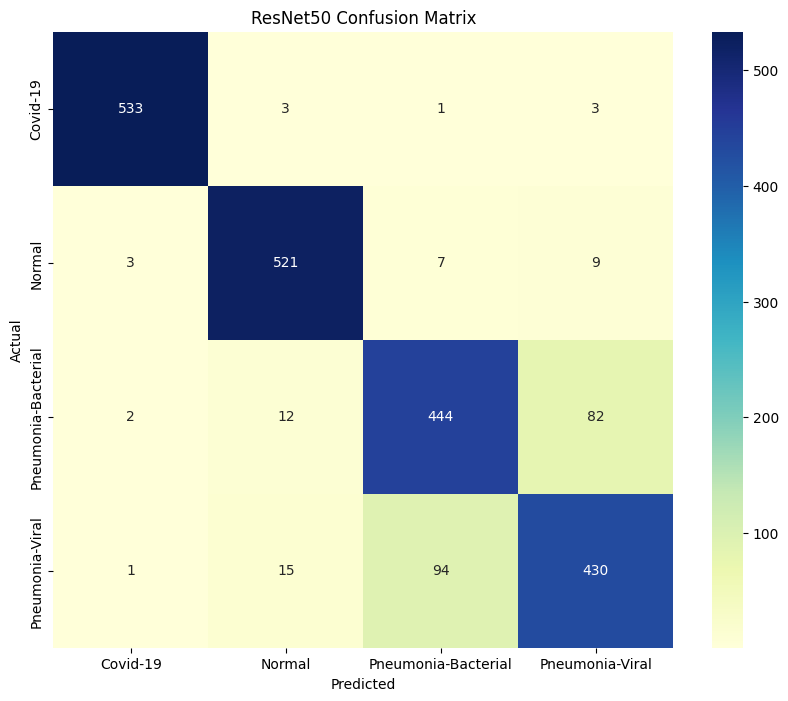


Classification Report:

                     precision    recall  f1-score   support

           Covid-19       0.99      0.99      0.99       540
             Normal       0.95      0.96      0.96       540
Pneumonia-Bacterial       0.81      0.82      0.82       540
    Pneumonia-Viral       0.82      0.80      0.81       540

           accuracy                           0.89      2160
          macro avg       0.89      0.89      0.89      2160
       weighted avg       0.89      0.89      0.89      2160



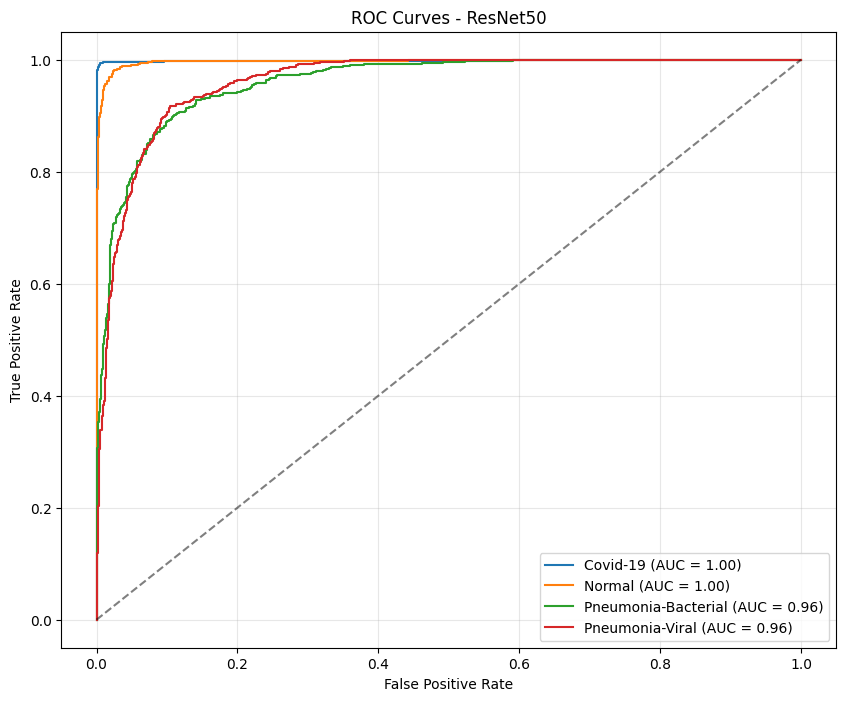

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 1. Load Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "test"),
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

# 2. Generate Predictions
print("Evaluating ResNet50...")
y_true = []
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- Metric A: Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet50 Confusion Matrix')
plt.show()

# --- Metric B: Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- Metric C: ROC Curves & AUC ---
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    y_true_bin = to_categorical(y_true, num_classes=4)[:, i]
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - ResNet50')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()